In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -------------------------------------------------
# Create FrozenLake Environment
# CHANGED: Custom start and goal positions
# -------------------------------------------------

# S = Start, F = Frozen, H = Hole, G = Goal
# Start is now at (0, 2) and Goal is at (3, 0),
# instead of the default FrozenLake positions.
custom_map = [
    "FFSF",
    "FHFH",
    "FFFF",
    "GFHF"
]

env = gym.make(
    "FrozenLake-v1",
    desc=custom_map,
    is_slippery=True
)

print("Custom FrozenLake map:")
for row in custom_map:
    print(row)

print("\nStart state: custom position (0, 2)")
print("Goal state: custom position (3, 0)")


Custom FrozenLake map:
FFSF
FHFH
FFFF
GFHF

Start state: custom position (0, 2)
Goal state: custom position (3, 0)


In [9]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.001          # Learning rate
gamma = 0.99         # Discount factor

# CHANGED: Epsilon is controlled by a variable range
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

# Initial epsilon value is taken from epsilon_start
epsilon = epsilon_start


In [10]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((env.observation_space.n, env.action_space.n))


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using epsilon-greedy strategy.
    Epsilon is passed as a variable, so its value can change
    during training instead of remaining fixed.
    """
    if np.random.random() < epsilon:
        return env.action_space.sample()
    return np.argmax(Q[state])


In [11]:
# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

episode_rewards = []

# CHANGED: epsilon starts from epsilon_start and changes
# after every episode until it reaches epsilon_min.
epsilon = epsilon_start

for episode in range(num_episodes):
    state, _ = env.reset()
    action = epsilon_greedy_action(state, epsilon)
    total_reward = 0

    for step in range(max_steps_per_episode):
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        if done:
            Q[state, action] += alpha * (
                reward - Q[state, action]
            )
            total_reward += reward
            break

        next_action = epsilon_greedy_action(next_state, epsilon)

        # SARSA update:
        # Q(s,a) = Q(s,a) + alpha * [r + gamma*Q(s',a') - Q(s,a)]
        Q[state, action] += alpha * (
            reward + gamma * Q[next_state, next_action] - Q[state, action]
        )

        state = next_state
        action = next_action
        total_reward += reward

    episode_rewards.append(total_reward)

    # CHANGED: variable epsilon decay
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

state_values = np.max(Q, axis=1)
learned_policy = np.argmax(Q, axis=1)

print("Final epsilon value:", epsilon)


Final epsilon value: 0.05


In [12]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [13]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)



Final Q-table:
[[0.073 0.003 0.004 0.002]
 [0.001 0.019 0.    0.001]
 [0.001 0.008 0.    0.001]
 [0.    0.    0.    0.005]
 [0.007 0.15  0.008 0.001]
 [0.    0.    0.    0.   ]
 [0.    0.    0.006 0.   ]
 [0.    0.    0.    0.   ]
 [0.445 0.045 0.036 0.005]
 [0.002 0.088 0.    0.001]
 [0.    0.001 0.    0.018]
 [0.002 0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.009 0.004 0.    0.103]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.073 0.019 0.008 0.005]
 [0.15  0.    0.006 0.   ]
 [0.445 0.088 0.018 0.002]
 [0.    0.103 0.    0.   ]]

Learned Policy:
[['L' 'D' 'D' 'U']
 ['D' 'L' 'R' 'L']
 ['L' 'D' 'U' 'L']
 ['L' 'U' 'L' 'L']]

Average reward over last 1000 episodes: 0.13


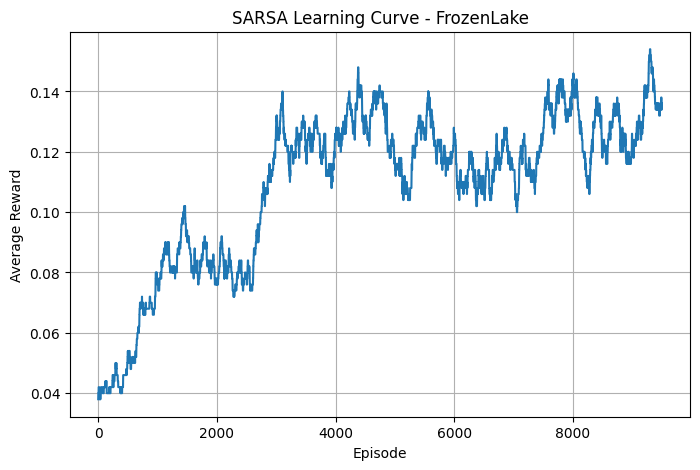

In [14]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("SARSA Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()